<a href="https://colab.research.google.com/github/MandakiniTraning/PINN/blob/main/PINN_heat_diffusion_1D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.19.0


### 1D Heat Diffusion Equation

The problem we're solving is the 1D heat diffusion equation:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

with initial and boundary conditions.

For this example, let's consider a domain $x \in [0, 1]$ and $t \in [0, 1]$.

**Parameters:**
- Thermal diffusivity $\alpha = 0.01$

**Initial Condition (IC):**
- At $t=0$, $u(x, 0) = \sin(\pi x)$

**Boundary Conditions (BCs):**
- At $x=0$, $u(0, t) = 0$
- At $x=1$, $u(1, t) = 0$


In [3]:
# Define the physical parameters
alpha = 0.01

# Define the PINN model
def build_pinn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(2,)), # Input: (x, t)
        tf.keras.layers.Dense(20, activation='tanh', kernel_initializer='glorot_normal'),
        tf.keras.layers.Dense(20, activation='tanh', kernel_initializer='glorot_normal'),
        tf.keras.layers.Dense(20, activation='tanh', kernel_initializer='glorot_normal'),
        tf.keras.layers.Dense(1) # Output: u(x, t)
    ])
    return model

model = build_pinn_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 921 (3.60 KB)

 Trainable params: 921 (3.60 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Define the loss function components

# Physics-informed loss (PDE residual)
def pde_loss(model, x, t):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(t)
        X = tf.stack([x[:,0], t[:,0]], axis=1)
        u = model(X)

        u_x = tape.gradient(u, x)
        u_t = tape.gradient(u, t)

        u_xx = tape.gradient(u_x, x)

    del tape

    # Heat equation: du/dt - alpha * d2u/dx2 = 0
    pde_residual = u_t - alpha * u_xx
    return tf.reduce_mean(tf.square(pde_residual))

# Initial condition loss
def ic_loss(model, x_ic, t_ic, u_ic_true):
    X_ic = tf.stack([x_ic[:,0], t_ic[:,0]], axis=1)
    u_ic_pred = model(X_ic)
    return tf.reduce_mean(tf.square(u_ic_pred - u_ic_true))

# Boundary condition loss
def bc_loss(model, x_bc, t_bc, u_bc_true):
    X_bc = tf.stack([x_bc[:,0], t_bc[:,0]], axis=1)
    u_bc_pred = model(X_bc)
    return tf.reduce_mean(tf.square(u_bc_pred - u_bc_true))

In [5]:
# Generate training data points

# Collocation points (for PDE residual)
num_collocation_points = 10000
x_col = tf.random.uniform((num_collocation_points, 1), minval=0.0, maxval=1.0, dtype=tf.float32)
t_col = tf.random.uniform((num_collocation_points, 1), minval=0.0, maxval=1.0, dtype=tf.float32)

# Initial condition points (t=0)
num_ic_points = 500
x_ic = tf.random.uniform((num_ic_points, 1), minval=0.0, maxval=1.0, dtype=tf.float32)
t_ic = tf.zeros_like(x_ic, dtype=tf.float32)
u_ic_true = tf.sin(np.pi * x_ic) # u(x,0) = sin(pi*x)

# Boundary condition points (x=0 and x=1)
num_bc_points = 200
t_bc = tf.random.uniform((num_bc_points, 1), minval=0.0, maxval=1.0, dtype=tf.float32)
x_bc0 = tf.zeros_like(t_bc, dtype=tf.float32)
u_bc0_true = tf.zeros_like(t_bc, dtype=tf.float32) # u(0,t) = 0

x_bc1 = tf.ones_like(t_bc, dtype=tf.float32)
u_bc1_true = tf.zeros_like(t_bc, dtype=tf.float32) # u(1,t) = 0

x_bc = tf.concat([x_bc0, x_bc1], axis=0)
t_bc = tf.concat([t_bc, t_bc], axis=0)
u_bc_true = tf.concat([u_bc0_true, u_bc1_true], axis=0)

# Create an optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

@tf.function
def train_step():
    with tf.GradientTape() as tape:
        # Calculate individual losses
        loss_pde = pde_loss(model, x_col, t_col)
        loss_ic = ic_loss(model, x_ic, t_ic, u_ic_true)
        loss_bc = bc_loss(model, x_bc, t_bc, u_bc_true)

        # Combine losses (you can use weighting if needed)
        total_loss = loss_pde + loss_ic + loss_bc

    # Compute gradients and update weights
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss_pde, loss_ic, loss_bc, total_loss

# Training loop
epochs = 5000
history = {'pde_loss': [], 'ic_loss': [], 'bc_loss': [], 'total_loss': []}

for epoch in range(epochs):
    loss_pde, loss_ic, loss_bc, total_loss = train_step()

    history['pde_loss'].append(loss_pde.numpy())
    history['ic_loss'].append(loss_ic.numpy())
    history['bc_loss'].append(loss_bc.numpy())
    history['total_loss'].append(total_loss.numpy())

    if epoch % 500 == 0:
        print(f'Epoch {epoch}: PDE Loss: {loss_pde:.4e}, IC Loss: {loss_ic:.4e}, BC Loss: {loss_bc:.4e}, Total Loss: {total_loss:.4e}')

print(f'Final Total Loss: {total_loss:.4e}')

Epoch 0: PDE Loss: 6.3238e-02, IC Loss: 3.2000e-01, BC Loss: 2.6109e-02, Total Loss: 4.0935e-01
Epoch 500: PDE Loss: 7.3593e-04, IC Loss: 1.0160e-03, BC Loss: 2.3234e-04, Total Loss: 1.9843e-03
Epoch 1000: PDE Loss: 2.7193e-04, IC Loss: 2.4506e-04, BC Loss: 4.9988e-05, Total Loss: 5.6698e-04
Epoch 1500: PDE Loss: 1.3863e-04, IC Loss: 8.8945e-05, BC Loss: 2.6189e-05, Total Loss: 2.5377e-04
Epoch 2000: PDE Loss: 8.0999e-05, IC Loss: 4.3800e-05, BC Loss: 1.0234e-05, Total Loss: 1.3503e-04
Epoch 2500: PDE Loss: 4.9933e-05, IC Loss: 3.4390e-05, BC Loss: 1.8033e-05, Total Loss: 1.0236e-04
Epoch 3000: PDE Loss: 2.9010e-05, IC Loss: 1.7532e-05, BC Loss: 6.2939e-06, Total Loss: 5.2836e-05
Epoch 3500: PDE Loss: 1.7026e-05, IC Loss: 1.3233e-05, BC Loss: 5.8378e-06, Total Loss: 3.6097e-05
Epoch 4000: PDE Loss: 1.0974e-05, IC Loss: 9.9367e-06, BC Loss: 5.5476e-06, Total Loss: 2.6459e-05
Epoch 4500: PDE Loss: 7.7822e-06, IC Loss: 7.3839e-06, BC Loss: 5.0881e-06, Total Loss: 2.0254e-05
Final Total Lo

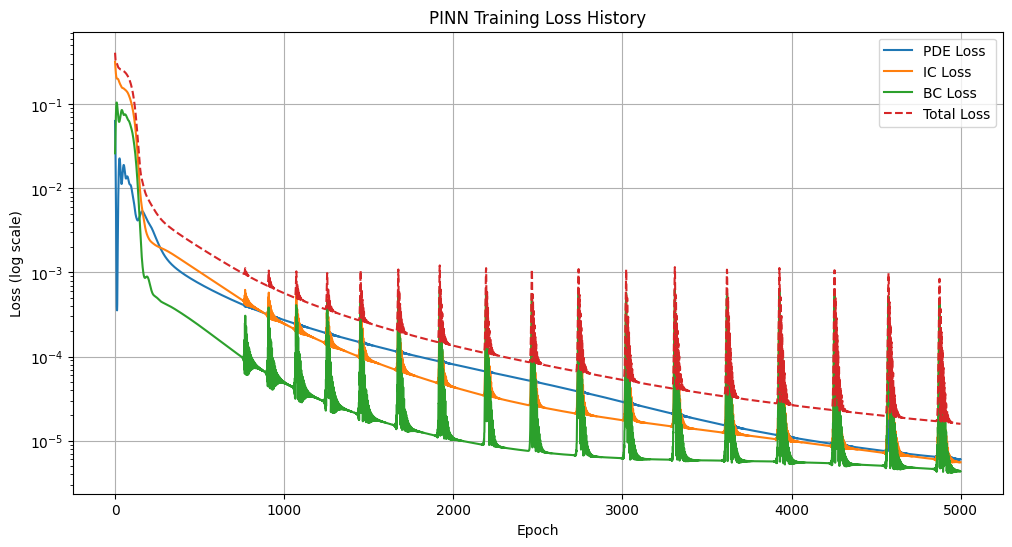

In [6]:
# Plotting the losses
plt.figure(figsize=(12, 6))
plt.plot(history['pde_loss'], label='PDE Loss')
plt.plot(history['ic_loss'], label='IC Loss')
plt.plot(history['bc_loss'], label='BC Loss')
plt.plot(history['total_loss'], label='Total Loss', linestyle='--')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('PINN Training Loss History')
plt.legend()
plt.grid(True)
plt.show()

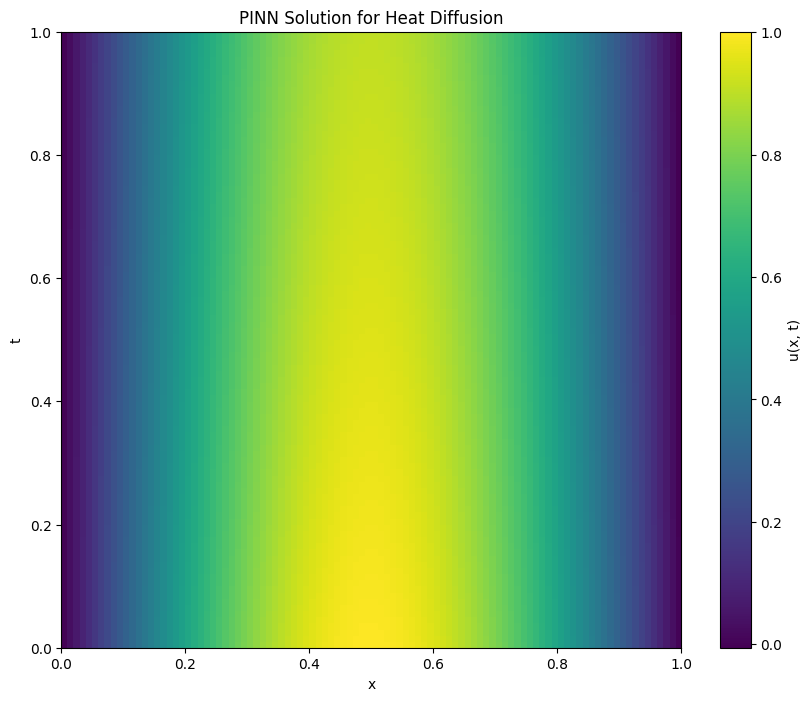

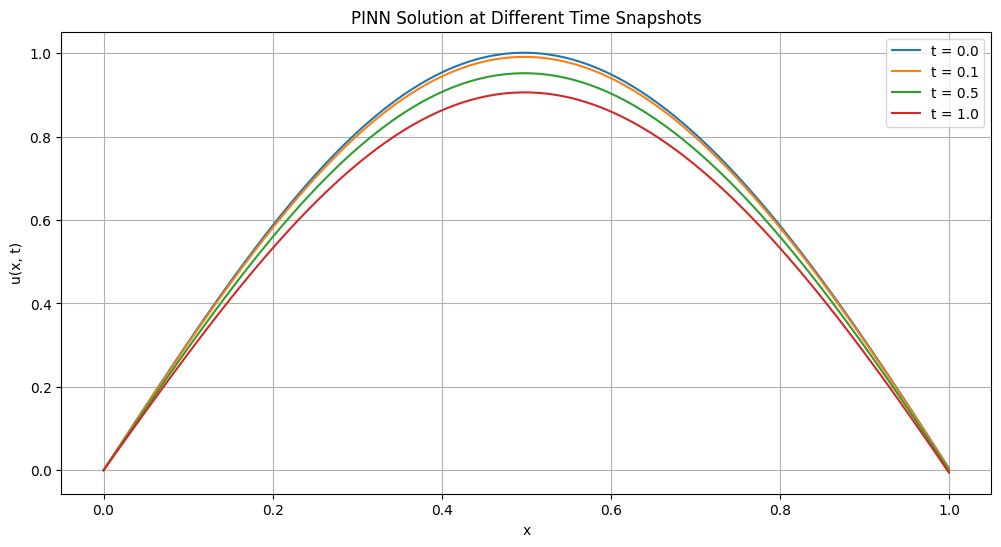

In [7]:
# Visualize the solution

# Create a grid for prediction
N = 100
x_plot = np.linspace(0, 1, N).reshape(-1, 1)
t_plot = np.linspace(0, 1, N).reshape(-1, 1)
X_mesh, T_mesh = np.meshgrid(x_plot, t_plot)

x_flat = X_mesh.flatten().reshape(-1, 1)
t_flat = T_mesh.flatten().reshape(-1, 1)

# Predict using the trained model
input_data = tf.constant(np.hstack([x_flat, t_flat]), dtype=tf.float32)
u_pred_flat = model(input_data).numpy()
u_pred_mesh = u_pred_flat.reshape(N, N)

# Plot the predicted solution
plt.figure(figsize=(10, 8))
plt.imshow(u_pred_mesh, extent=[0, 1, 0, 1], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='u(x, t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('PINN Solution for Heat Diffusion')
plt.show()

# Plot solution at specific time steps
plt.figure(figsize=(12, 6))
t_snapshots = [0.0, 0.1, 0.5, 1.0]

for t_snap in t_snapshots:
    t_vec = t_snap * np.ones_like(x_plot)
    input_snap = tf.constant(np.hstack([x_plot, t_vec]), dtype=tf.float32)
    u_snap_pred = model(input_snap).numpy()
    plt.plot(x_plot, u_snap_pred, label=f't = {t_snap:.1f}')

plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title('PINN Solution at Different Time Snapshots')
plt.legend()
plt.grid(True)
plt.show()